In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch

import pytorch_lightning as pl
from pytorch_lightning.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
    RichProgressBar,
)
from pytorch_lightning.loggers import TensorBoardLogger
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

from src.dataset import *
from src.lightning import *
from src.models import *
from src.params import *
from src.utils import *

import optuna, optuna_dashboard
from optuna.trial import TrialState


In [2]:
# instantiate model with best params 

storage = optuna.storages.RDBStorage("sqlite:///optuna_brain_v2.db")
study = optuna.load_study(study_name="brain_optuna_v2", storage= storage)

In [3]:
study.best_params

{'learning_rate': 0.0028273119832751066,
 'kernel_size': 5,
 'dim_0': 117,
 'dim_1': 52,
 'dim_2': 60,
 'dim_3': 64,
 'dim_4': 103,
 'dim_5': 226}

In [4]:
best_model = OptunaModel(**BEST_MODEL_PARAMS)

In [5]:
lit_best = BrainLightning(model = best_model, 
                          n_classes= 6,
                          lr = BEST_TRAINING_PARAMS["lr"],
                          mixup = True,
                          mixup_alpha= BEST_TRAINING_PARAMS["mixup_alpha"],
                          weight_decay= BEST_TRAINING_PARAMS["weight_decay"],
                          t_max= BEST_TRAINING_PARAMS["t_max"],
                          scheduler= True)

In [6]:
files_dir = PROCESSED_DIR / "cropped" / "files"
metadata = pd.read_csv(DATA_DIR / "train.csv")
dm = BrainDataModule(metadata=metadata, spec_dir= files_dir, batch_size= 32, num_workers= 8, verbose= True)

In [7]:
callbacks = [
    ModelCheckpoint(
        dirpath= "checkpoints/final",
        monitor= "val_loss",
        mode= "min",
        save_top_k= 1,
        save_last= True,
        filename= "{epoch:02d}-{val_loss:.3f}",
    ),
    EarlyStopping(
        monitor= "val_loss",
        patience = 5,
        mode= "min",
        min_delta= 1e-3
    ),
    LearningRateMonitor(logging_interval="epoch"),
    RichProgressBar(),
    
]

logger = TensorBoardLogger(save_dir="logs/", name="final", version=None)

In [8]:
trainer = pl.Trainer(
    accelerator= "auto",
    devices= "auto",
    precision = "bf16-mixed",
    callbacks = callbacks,
    logger= logger,
    max_epochs= BEST_TRAINING_PARAMS["n_epochs"],
    enable_progress_bar= True,
    log_every_n_steps= 10
)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [9]:
trainer.fit(lit_best, datamodule= dm)

Filtered by 1: 17089/17089 kept
[setup] Loading splits from cache: /Users/pablorougerie/code/Projets/brain_waves/data/cache/5_at_seed_273_min_vote_1.json
[setup] Cache loaded — 5 folds found
[Check] Train set distribution:
 expert_consensus
GPD        0.105983
GRDA       0.107885
LPD        0.151331
LRDA       0.054930
Other      0.425541
Seizure    0.154330
[Check] Val distribution:
 expert_consensus
GPD        0.106234
GRDA       0.107989
LPD        0.151302
LRDA       0.054726
Other      0.425519
Seizure    0.154229
[Check] Train: 13672 samples, 1558 patients
[Check] Val:   3417 samples, 392 patients
[Check] Top 5 patients train:
patient_id
30631    270
28330    250
38549    205
35225    189
56450    182
[Check] Top 5 patients val:
patient_id
17408    177
35627    171
1218     122
18815     92
55148     92


/Users/pablorougerie/code/Projets/brain_waves/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/pablorougerie/code/Projets/brain_waves/notebooks/checkpoints/final exists and is not empty.
/Users/pablorougerie/code/Projets/brain_waves/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision bf16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ OptunaModel │  1.1 M │ train │     0 │
│ 1 │ criterion │ KLDivLoss   │      0 │ train │     0 │
└───┴───────────┴─────────────┴────────┴───────┴───────┘

Trainable params: 1.1 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 M                                                                                                
Total estimated model params size (MB): 4                                                                          
Modules in train mode: 48                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

Epoch 029 - train_loss: 0.4551 - lr: 1.41e-04

Epoch 030 | val_loss:   0.6843

Epoch 030 - train_loss: 0.4564 - lr: 9.11e-05

Epoch 031 | val_loss:   0.6952

Epoch 031 - train_loss: 0.4545 - lr: 5.19e-05

In [10]:
def plot_losses(log_dir="logs/final"):
    versions = sorted(
        Path(log_dir).glob("version_*"),
        key=lambda p: int(p.name.split("_")[-1])
    )
    ea = EventAccumulator(str(versions[-1]))
    ea.Reload()

    def to_df(tag):
        events = ea.Scalars(tag)
        # e.step is global step (batches), not epoch — use index instead
        return pd.DataFrame({"epoch": range(len(events)), tag: [e.value for e in events]})

    train = to_df("train_loss")
    val   = to_df("val_loss")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(train["epoch"], train["train_loss"], label="train loss")
    ax.plot(val["epoch"],   val["val_loss"],     label="val loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("KL Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


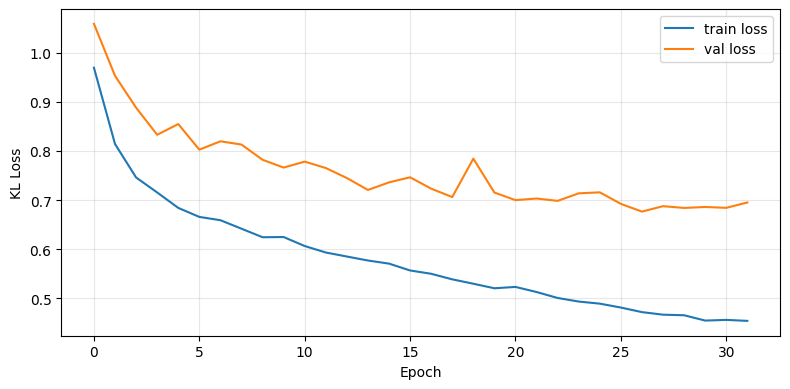

In [11]:
plot_losses()


In [12]:
best_score = callbacks[0].best_model_score
best_path = callbacks[0].best_model_path
print(f"Best checkpoint: {best_path}")
print(f"Best val_loss: {best_score:.4f}")

Best checkpoint: /Users/pablorougerie/code/Projets/brain_waves/notebooks/checkpoints/final/epoch=26-val_loss=0.677.ckpt
Best val_loss: 0.6766
